In [1]:
# Debt Sustainability Analysis – Finland

"""
This notebook simulates Finland's public debt dynamics using
the standard debt sustainability equation:

d_{t+1} = (1+r)/(1+g) * d_t - pb

where
d  = debt/GDP
r  = interest rate
g  = GDP growth
pb = primary balance (% GDP)
"""

"\nThis notebook simulates Finland's public debt dynamics using\nthe standard debt sustainability equation:\n\nd_{t+1} = (1+r)/(1+g) * d_t - pb\n\nwhere\nd  = debt/GDP\nr  = interest rate\ng  = GDP growth\npb = primary balance (% GDP)\n"

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/fi_gross_debt_pc_gdp.csv")
df.tail()

,geo,time,value
10,FI,2020,75.3
11,FI,2021,73.1
12,FI,2022,74.0
13,FI,2023,77.1
14,FI,2024,82.5


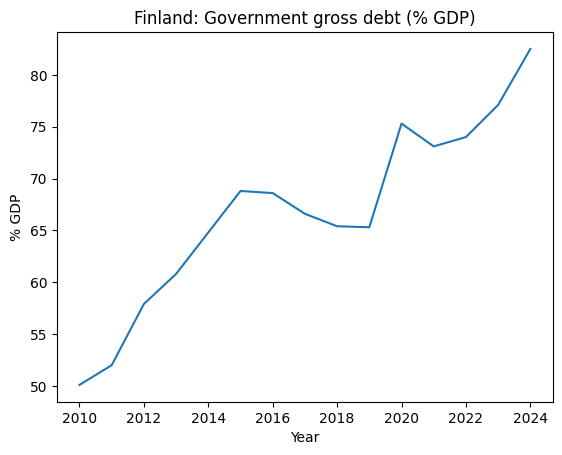

In [3]:
plt.figure()
plt.plot(df["time"], df["value"])
plt.title("Finland: Government gross debt (% GDP)")
plt.xlabel("Year")
plt.ylabel("% GDP")
plt.show()

In [4]:
def simulate_debt(d0, r, g, pb, years=20):
    d = [d0]
    for _ in range(years):
        d_next = (1+r)/(1+g) * d[-1] - pb
        d.append(d_next)
    return d

In [5]:
d0 = df["value"].iloc[-1]

baseline = simulate_debt(d0, r=0.03, g=0.02, pb=0.00)
high_rate = simulate_debt(d0, r=0.05, g=0.02, pb=0.00)
low_growth = simulate_debt(d0, r=0.03, g=0.00, pb=0.00)
fiscal_adjust = simulate_debt(d0, r=0.03, g=0.02, pb=0.01)

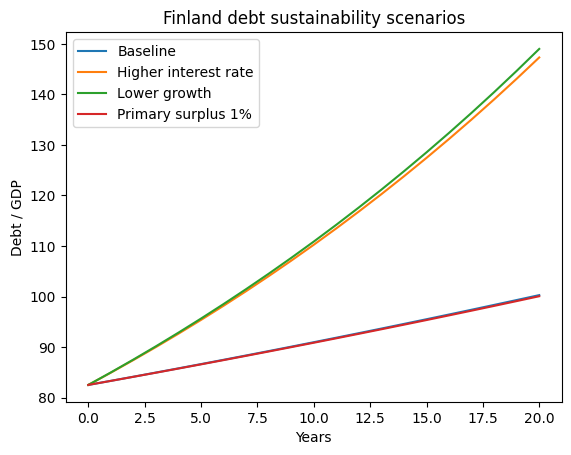

In [6]:
plt.figure()
plt.plot(baseline, label="Baseline")
plt.plot(high_rate, label="Higher interest rate")
plt.plot(low_growth, label="Lower growth")
plt.plot(fiscal_adjust, label="Primary surplus 1%")
plt.legend()
plt.title("Finland debt sustainability scenarios")
plt.xlabel("Years")
plt.ylabel("Debt / GDP")
plt.show()

## Interpretation

The debt sustainability simulations highlight three key insights:

1. **Interest_growth differential matters**
   When the interest rate exceeds GDP growth (r > g), debt increases rapidly even with a balanced primary budget.

2. **Low growth is particularly dangerous**
   Weak economic growth leads to a rising debt ratio, as the denominator (GDP) grows slowly while debt dynamics worsen.

3. **Fiscal adjustment stabilises debt**
   A primary surplus of around 1% of GDP significantly stabilises the debt path, even under moderate interest rates.

Overall, Finland’s debt trajectory is highly sensitive to macroeconomic conditions.
Sustainable debt levels require either sufficient growth, low interest rates,
or persistent primary surpluses.